## 머신러닝 : 모델 평가 (2)

## 데이터 분할(Data Split)

(1) 훈련데이터셋으로 평가하기  
- 훈련 데이터로 학습했기 때문에 훈련 데이터로 평가하면 정확도는 거의 100%에 가깝게 나오므로, 높은 정확도가 나온다고 생각.
- 하지만 새로운 데이터(미래 데이터)에서는 엉망일 수 있다.

(2) 독립적인 테스트 데이터셋으로 평가하기(충분한 데이터가 있을 때)
- 이상적으로는 초반에 훈련용, 테스트용으로 완전히 분리하는 것이 좋다.
    - 데이터가 아주 많거나 자연스럽게 훈련/테스트로 나눌 수 잇는 경우에 사용..
    - 훈련 때 전혀 관여하지 않고 독립적이기에, 모델 평가가 아주 객관적!

(3) Hold-Out Validation : 데이터 나누어 쓰기
- 별도의 외부 테스트가 없다면, 현재 가진 데이터를 쏘개서 훈련과 테스트에 사용.

- 하지만, 평가 결과가 데이터 분할에 따라 달라질 수 있다.
    - 클래스 불균형 문제를 피하기 위해 **층화추출**을 사용하는 것이 중요

- 층화(Stratification) : 데이터를 분할할 때, 각 클래스나 중요한 그룹의 비율이 훈련데이터와 테스트 데이터에 거의 동일하게 유지되도록 샘플링하는 것

```
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    **stratify = y**
    random_state = 42
)
```

(4) Repeated Hold-out Validation
- 기존의 Hold out 방법의 문제 == 한번의 분할에 평가 결과가 좌우된다.
- 그래서 여러 번 다르게 무작위 분할해보고 학습/평가 후 성능을 평가 내는 것

- 반복과정들에서 겹치는 데이터 문제가 발생!
    - 여러번 평가하지만, 테스트에 쓰이는 데이터들이 서로 독립적이지 않을 수 있음.

## 교차 검증(Cross Validation)

**K-Fold Cross-Validation(교차검증)**
- 데이터를 K개의 동등한 크기로 나누어, 번갈아 가면서 검증/학습하는 방식
    - 운적인 영향을 최소화하기
    - 특정 데이턱 우연히 테스트 셋으로 가서 성능이 왜곡되는 걸 막아주는 기법

**HOW**
1. 만약 K=5이라면, 전체 데이터를 5등분
2. 그 중 1등분은 테스트, 나머지 4등분은 훈련으로 모델을 학습/평가
3. 그 다음에는 다른 등분을 테스트로 나머지를 훈련으로 해서 다시 평가
4. 각각의 등분이 한 번씩 테스트 셋 역할을 하도록 총 5번 실험
5. 결국 전체 데이터의 모든 부분이 한번씩 테스트세 사용됨.

- 5개의 테스트 결과를 평균내어 최종 성능 평가치로 삼는다.

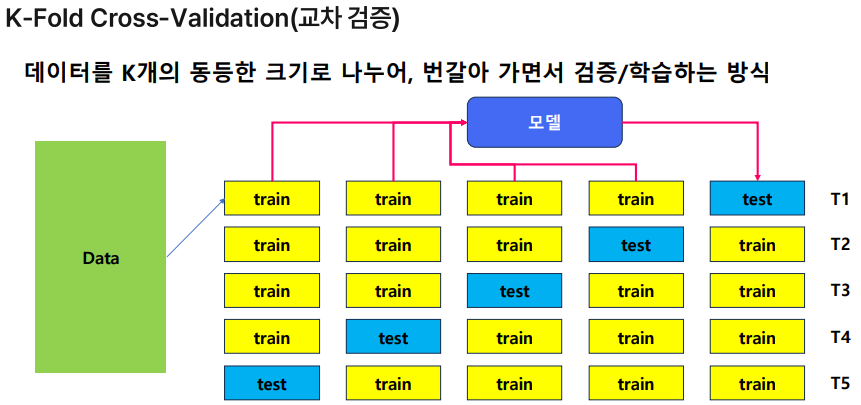

**장점**
- 데이터를 최대한 효율적으로 사용(데이터가 많지 않을 때 유리)
- 평가가 안정적(특정 분할에 성능이 치우치지 않음.)
- 일반화 성능을 더 정확하게 측정
  

**단점**  
- 계산량이 K배 많아짐.
- 데이터가 크면 연산의 부담이 큼
- 시간이 오래 걸릴 수 있음.

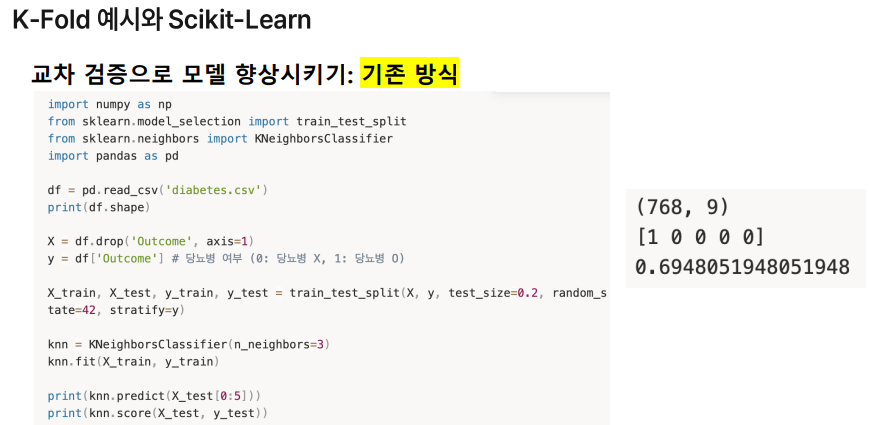

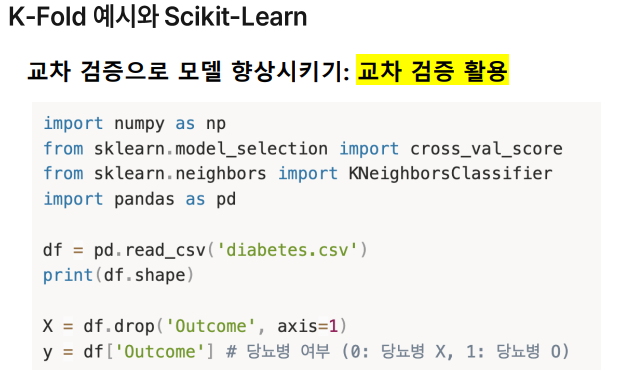
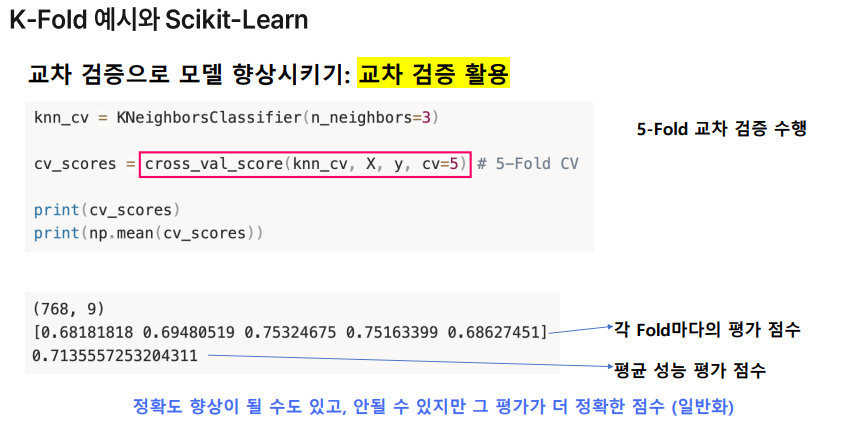

## 하이퍼 파라미터 튜닝

**하이퍼파라미터**
- 모델이 학습하기 전에 사람이 직접 정해줘야 하는 값
    - knn의 k rkqt
    - 결정트리의 max_depth
    - k-means의 k

- 하이퍼 파라미터 값이 모델 성능을 크게 좌우한다.!
    - 적절한 값을 찾아야 모델이 일반화 성능을 잘 낼 수 있다.

여러 후보를 시헙해보고 제일 성능이 나는 하이퍼파라미터를 선택 -> 이때 성능 측정 = 교차 검증(Cross-Validation)  
- 기본적으로 Manual Search : 사람이 직접 경험적 감각, 도메인 지식, 반복 실험을 통해 수동으로 탐색

### (1) GridSearch

- 모든 조합을 다 시도
    - 파라미터 값 조합의 격자를 생성하여, 모든 조합을 시도
        - 성능이 제일 좋은 조합을 선택
    
- 장점
    - 모든 조합을 시도하므로, 최적 값을 찾을 확률이 크다.
- 단점
    - 느릴 수 있고, 시도 조합 증가할 시 연산량 폭발

**주의할점**  
- Test는 절대 쓰지 말것
    - 튜닝을 오로지 train 데이터를 가지고 CV로만 진행
- 튜닝 후 반드시 Test로 최종 평가하기
    - CV 점수는 모델 선택을 위한 참고용, 최종 성능은 Test에서 재확인 해야 함
- 과적합의 가능성이 있다.
    - 파라미터 후보가 너무 많으면 CV에 과적합될 가능성 있음.

### 하이퍼 파라미터 튜닝(2) : RandomizedSearch

- 조합 후보 중 일부 랜덤하게 시도 : 대게 성능이 좋음
    - 지정된 하이퍼파라미터 범위에서 무작위로 조합을 선택하여 일정 횟수만 탐색

- 장단점
    - 장점
        - 빠르고, 고차원에서 효율적이다.
    - 단점
        - 완전 최적 값을 못 찾을 수도 있다.
    
- Scikit-Learn에서 RandomizedSeach() 클래스
    - n_iter 옵션으로 탐색 범위 조정

## 앙상블 러닝(Ensemble Learning)

### Tree 기반 모델과 앙상블 러닝

**앙상블 학습**  
여러 개의 분류기(classifier)를 생성하고, 그 예측을 결합함으로써 보다 정확한 예측을 도출하는 기법
- 강력한 하나의 모델을 사용하는 대신, 보다 약한 모델 여러 개를 조합하여 더 정확한 예측에 도움  

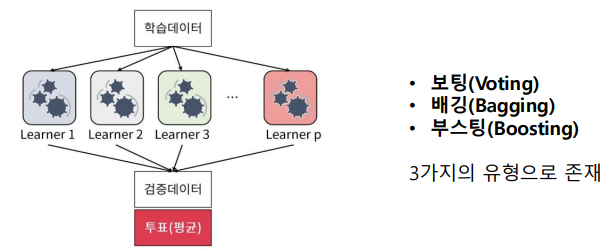


**앙상블 학습 : 보팅 (Voting)**
- 여러 개의 분류기(Classifier)가 투표를 통해 최종 예측 결과를 결정하는 ㅂ아식
    - 서로 다른 유형의 알고리즘 기반의 분류기 사용

### 랜덤포레스트

**기존의 Decision Tree의 문제점?**
1. 과적합에 쉽게 빠진다.
    - 데이터를 너무 세밀하게 쪼갬
    - 조금만 특징이 달라도 트리 구조가 크게 변함
    - 깊이가 깊을수록 과적합이 심하다.
2. 데이터 노이즈에 민감하디.
    - 이상치 때문에 트리 분기 기준이 아예 달라질 수 이싿.
    - 작은 변화에도 트리 구조가 크게 달라지기에 예측 불안정
3. 단일 모델의 일반화 성능이 낮다.
    - 트리 하나는 예측이 들쑥날쓱
    - 복잡한 데이터일수록 예측 성능 떨어짐

**랜덤 포레스트(Random Forest)**
- 여러 개의 결정 트리들을 임의적으로 학습하는 방식의 앙상블 방법
- 여러 학습기들을 생성한후 ,이를 선형 결함하여 최종 학습기를 만드는 방법

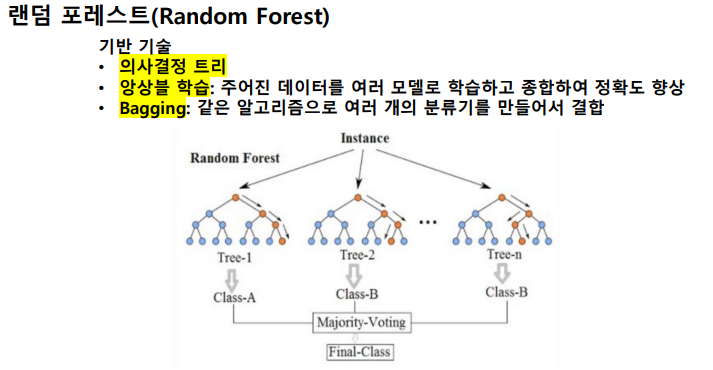

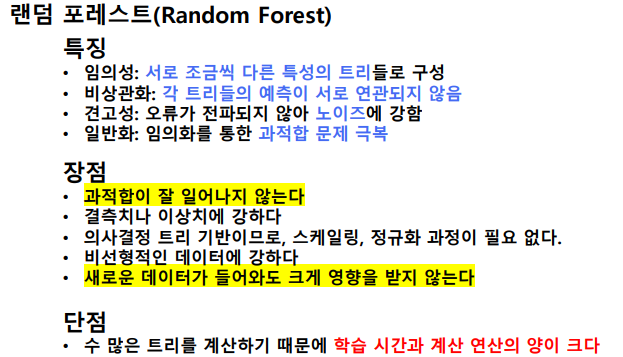

**랜덤 포레스트의 하이퍼파라미터**
- n_estimators: 앙상블을 위한 트리의 개수(디폴트=100개)
- max_features: 노드 분할 시, 고려하는 최대 feature의 개수
- criterion: 분할 기준 지표(gini, entropy)
- max_depth: 각 트리에서 허용되는 최대 깊이(디폴트=None; 리프 노드까지 완전 분할)
- min_samples_leaf: 리프 노드가 가져야 하는 최소 샘플 개수(디폴트=1개)
- min_samples_split: 노드 분할시키기 위해 필요한 최소 샘플 개수 (디폴트=2개)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_trian,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_trian)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)